# Multi-objective Diet Optimization

Bioinspired Algorithms for Optimization (BAO) project assignment.

**Pipeline coverage**
- 2 evolutionary algorithms (NSGA-II, PAES) and 2 swarm intelligence algorithms (scalarised PSO, MO-PSO).
- 2 representations (direct_index, random_key) compared on NSGA-II.
- 3 constraint handling techniques (repair, penalty, death-penalty) compared on NSGA-II.
- Hyperparameter sensitivity sweep within each algorithm (NSGA-II, PAES, MOPSO, PSO-scalar).
- Multi-objective metrics: hypervolume, IGD, Schott's spacing.
- 30 stochastic runs per configuration.
- Statistical tests: Friedman omnibus + pairwise Mann-Whitney with Holm correction.
- Convergence and diversity plots.

**Manual setup required**
1. Restore `food_database_dump.sql` into MySQL.
2. Copy `.env.example` to `.env` and set `DB_PASSWORD`.
3. `pip install -r requirements.txt && pip install -e .`.
4. Run `python verify_db.py` once to confirm the connection.
5. Run all cells in order.

In [3]:
from pathlib import Path
import time

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from diet_bao.experiment.experiment_loader import (
    AlgorithmConfig,
    BenchmarkPlan,
    default_plan,
    load_real_dataset,
    run_all_subjects,
    summarize_results,
)
from diet_bao.experiment.visualization import (
    plot_convergence,
    plot_front_size_over_time,
    plot_objective_min_over_time,
    plot_pareto,
    plot_reference_front,
    plot_metric_box,
)
from diet_bao.metrics import hypervolume_2d, schott_spacing
from diet_bao.metrics.igd import inverted_generational_distance, union_reference_front
from diet_bao.ea.nsga2_diet import run_nsga2
from diet_bao.ea.paes_diet import run_paes
from diet_bao.si.mopso_diet import run_mopso
from diet_bao.si.pso_diet import run_pso
from diet_bao.constraints import REPAIR, PENALTY, DEATH_PENALTY
from diet_bao.representations import DIRECT_INDEX, RANDOM_KEY
from stac.stat_tests import (
    average_ranks,
    friedman_test,
    mann_whitney_p_value,
    pairwise_post_hoc,
)

Path('experiments').mkdir(parents=True, exist_ok=True)

## 1. Load real dataset and inspect subjects

In [4]:
foods, subjects = load_real_dataset()
subjects_df = pd.DataFrame([s.__dict__ for s in subjects])
print(f'foods: {len(foods)}    subjects: {len(subjects)}')
display(subjects_df)
demo_subject = subjects[0]
print('Demo subject for plots:', demo_subject)

foods: 2616    subjects: 5


,sujeto_id,edad,calorias,gustos,disgustos,alergias
0,1,17,2877.19,"[AC, AD, MCA]","[BR, J, JA, JC, JK, JM, JR]","[S, SE, SEA, SEC, SN, SNA, SNC]"
1,2,30,2567.85,"[BAE, FC, FE]","[C, CA, CD, CDE, CDH]","[A, AB, AC, AD, AE, AF, AG, AI, AK, AM, AN, AO..."
2,3,40,3102.84,"[DAP, MAC, SEA]","[BH, BJS, MIG]","[PAC, PCA, SNC]"
3,4,55,1710.50,"[AF, BNH]","[MB, QA, QC]","[F, FA, FC, FE]"
4,5,72,1401.30,"[AM, JC]","[MG, MR]","[BA, BAB, BAE, BAH, BAK, BAR, BH]"


Demo subject for plots: SubjectProfile(sujeto_id=1, edad=17, calorias=2877.19, gustos=['AC', 'AD', 'MCA'], disgustos=['BR', 'J', 'JA', 'JC', 'JK', 'JM', 'JR'], alergias=['S', 'SE', 'SEA', 'SEC', 'SN', 'SNA', 'SNC'])


## 2. Single-run demo: Pareto fronts and convergence side-by-side

One run per algorithm with a small budget. Used to illustrate the shape of the search and to compute a per-subject reference front for IGD.

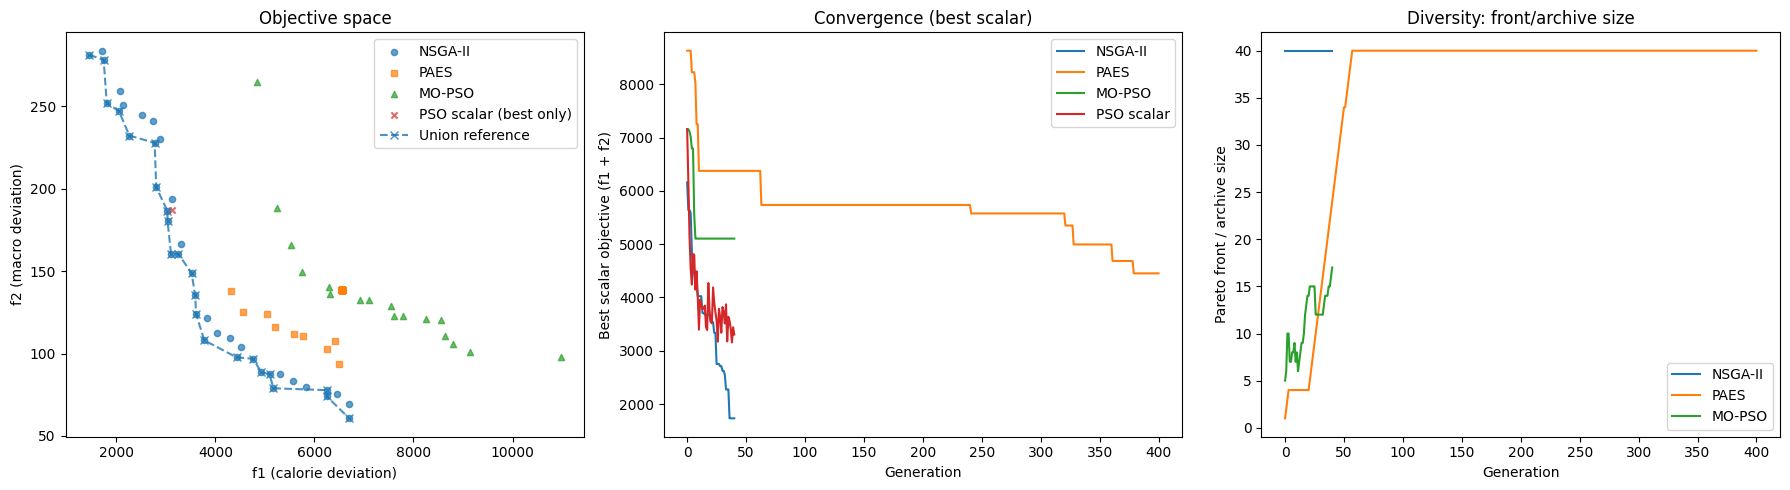

In [5]:
demo_kwargs = dict(pop_size=40, max_generations=40, seed=1)
demo_nsga = run_nsga2(foods, demo_subject.edad, demo_subject.calorias, representation=DIRECT_INDEX, constraint_handler=REPAIR, **demo_kwargs)
demo_paes = run_paes(foods, demo_subject.edad, demo_subject.calorias, representation=DIRECT_INDEX, constraint_handler=REPAIR, max_generations=400, max_archive_size=40, seed=1)
demo_pso = run_pso(foods, demo_subject.edad, demo_subject.calorias, representation=RANDOM_KEY, **demo_kwargs)
demo_mopso = run_mopso(foods, demo_subject.edad, demo_subject.calorias, representation=RANDOM_KEY, constraint_handler=REPAIR, max_archive_size=40, **demo_kwargs)

ref = union_reference_front(demo_nsga['front'], demo_paes['front'], demo_mopso['front'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_pareto(demo_nsga['front'], axes[0], label='NSGA-II', marker='o')
plot_pareto(demo_paes['front'], axes[0], label='PAES', marker='s')
plot_pareto(demo_mopso['front'], axes[0], label='MO-PSO', marker='^')
plot_pareto([demo_pso['best_f']], axes[0], label='PSO scalar (best only)', marker='x')
plot_reference_front(ref, axes[0], label='Union reference')
axes[0].legend(); axes[0].set_title('Objective space')

plot_convergence(demo_nsga['trace'], axes[1], label='NSGA-II')
plot_convergence(demo_paes['trace'], axes[1], label='PAES')
plot_convergence(demo_mopso['trace'], axes[1], label='MO-PSO')
plot_convergence(demo_pso['trace'], axes[1], label='PSO scalar')
axes[1].legend(); axes[1].set_title('Convergence (best scalar)')

plot_front_size_over_time(demo_nsga['trace'], axes[2], label='NSGA-II')
plot_front_size_over_time(demo_paes['trace'], axes[2], label='PAES')
plot_front_size_over_time(demo_mopso['trace'], axes[2], label='MO-PSO')
axes[2].legend(); axes[2].set_title('Diversity: front/archive size')

plt.tight_layout()
plt.savefig('experiments/demo_overview.png', dpi=150)
plt.show()

## 3. Hyperparameter sensitivity sweep

Within-algorithm hyperparameter sweep on a single representative subject (subject 1). Complements the cross-algorithm grid in section 4 (which sweeps algorithm x representation x constraint handler).

**Sweeps (5 replicates per configuration):**
- NSGA-II direct_index repair: mutation_rate in {0.05, 0.10, 0.20} at pop=60; pop_size in {40, 80} at mutation_rate=0.10.
- PAES direct_index repair: mutation_rate in {0.05, 0.10, 0.20} at archive=80; archive_size in {40, 80} at mutation_rate=0.10.
- MOPSO random_key repair: inertia in {0.5, 0.7, 0.9} at c1=c2=1.5; c1=c2 in {1.0, 2.0} at inertia=0.7.
- PSO-scalar random_key: objective weights (w1, w2) in {(1,1), (2,1), (1,2)}.

Output: `experiments/tuning_results.csv` plus a printed table identifying the best hyperparameter setting per algorithm.

In [6]:
from dataclasses import dataclass
from typing import Any, Callable

@dataclass(frozen=True)
class TuningConfig:
    config_id: str
    algorithm: str
    runner: Callable[..., dict[str, Any]]
    fixed_kwargs: dict[str, Any]

tuning_grid = []

# NSGA-II (direct_index + repair)
for mr in (0.05, 0.10, 0.20):
    tuning_grid.append(TuningConfig(f'nsga2_mut{mr}_pop60', 'NSGA-II', run_nsga2,
        dict(representation=DIRECT_INDEX, constraint_handler=REPAIR,
             pop_size=60, max_generations=60, mutation_rate=mr)))
for pop in (40, 80):
    tuning_grid.append(TuningConfig(f'nsga2_mut0.1_pop{pop}', 'NSGA-II', run_nsga2,
        dict(representation=DIRECT_INDEX, constraint_handler=REPAIR,
             pop_size=pop, max_generations=60, mutation_rate=0.10)))

# PAES (direct_index + repair)
for mr in (0.05, 0.10, 0.20):
    tuning_grid.append(TuningConfig(f'paes_mut{mr}_arch80', 'PAES', run_paes,
        dict(representation=DIRECT_INDEX, constraint_handler=REPAIR,
             pop_size=1, max_generations=400, mutation_rate=mr, max_archive_size=80)))
for arch in (40, 80):
    tuning_grid.append(TuningConfig(f'paes_mut0.1_arch{arch}', 'PAES', run_paes,
        dict(representation=DIRECT_INDEX, constraint_handler=REPAIR,
             pop_size=1, max_generations=400, mutation_rate=0.10, max_archive_size=arch)))

# MOPSO (random_key + repair)
for w in (0.5, 0.7, 0.9):
    tuning_grid.append(TuningConfig(f'mopso_w{w}_c1.5', 'MOPSO', run_mopso,
        dict(representation=RANDOM_KEY, constraint_handler=REPAIR,
             pop_size=40, max_generations=40, inertia=w, c1=1.5, c2=1.5,
             max_archive_size=40)))
for c in (1.0, 2.0):
    tuning_grid.append(TuningConfig(f'mopso_w0.7_c{c}', 'MOPSO', run_mopso,
        dict(representation=RANDOM_KEY, constraint_handler=REPAIR,
             pop_size=40, max_generations=40, inertia=0.7, c1=c, c2=c,
             max_archive_size=40)))

# PSO-scalar (random_key; scalarisation weights)
for w1, w2 in ((1.0, 1.0), (2.0, 1.0), (1.0, 2.0)):
    tuning_grid.append(TuningConfig(f'pso_w{w1:g}_{w2:g}', 'PSO-scalar', run_pso,
        dict(representation=RANDOM_KEY, pop_size=60, max_generations=60, w1=w1, w2=w2)))

n_runs_tune = 5
seed0_tune = 5000
print(f'Tuning grid: {len(tuning_grid)} configs × {n_runs_tune} replicates = {len(tuning_grid) * n_runs_tune} runs')

tuning_raw = []
tune_t0 = time.perf_counter()
for cfg in tuning_grid:
    for r in range(n_runs_tune):
        seed = seed0_tune + r
        t0 = time.perf_counter()
        res = cfg.runner(foods, demo_subject.edad, demo_subject.calorias,
                          seed=seed, **cfg.fixed_kwargs)
        dt = time.perf_counter() - t0
        tuning_raw.append((cfg, seed, res, dt))
    print(f'  done: {cfg.config_id:<24}  cumulative {time.perf_counter() - tune_t0:.1f}s')
print(f'\nTuning sweep elapsed: {time.perf_counter() - tune_t0:.1f}s')

Tuning grid: 18 configs × 5 replicates = 90 runs
  done: nsga2_mut0.05_pop60       cumulative 18.8s
  done: nsga2_mut0.1_pop60        cumulative 35.4s
  done: nsga2_mut0.2_pop60        cumulative 52.7s
  done: nsga2_mut0.1_pop40        cumulative 64.7s
  done: nsga2_mut0.1_pop80        cumulative 90.5s
  done: paes_mut0.05_arch80       cumulative 98.9s
  done: paes_mut0.1_arch80        cumulative 108.1s
  done: paes_mut0.2_arch80        cumulative 115.6s
  done: paes_mut0.1_arch40        cumulative 124.4s
  done: paes_mut0.1_arch80        cumulative 134.6s
  done: mopso_w0.5_c1.5           cumulative 138.5s
  done: mopso_w0.7_c1.5           cumulative 142.2s
  done: mopso_w0.9_c1.5           cumulative 146.0s
  done: mopso_w0.7_c1.0           cumulative 149.9s
  done: mopso_w0.7_c2.0           cumulative 153.7s
  done: pso_w1_1                  cumulative 156.8s
  done: pso_w2_1                  cumulative 160.1s
  done: pso_w1_2                  cumulative 164.2s

Tuning sweep elapsed

In [7]:
all_tune_fronts = [[tuple(p) for p in res['front']] for _, _, res, _ in tuning_raw]
tune_ref_front = union_reference_front(*all_tune_fronts)

def _hv_ref(front, pad=1.1):
    if not front:
        return (1.0, 1.0)
    return (max(p[0] for p in front) * pad + 1.0, max(p[1] for p in front) * pad + 1.0)

tuning_rows = []
for cfg, seed, res, dt in tuning_raw:
    front = [tuple(p) for p in res['front']]
    f1_best, f2_best = res['best_f']
    if front:
        hv = hypervolume_2d(front, reference=_hv_ref(front))
        igd = inverted_generational_distance(front, tune_ref_front) if tune_ref_front else 0.0
        sp = schott_spacing(front)
    else:
        hv, igd, sp = 0.0, float('inf'), 0.0
    tuning_rows.append({
        'config_id': cfg.config_id,
        'algorithm': cfg.algorithm,
        'seed': seed,
        'runtime_s': float(dt),
        'f1_best': float(f1_best),
        'f2_best': float(f2_best),
        'front_size': len(front),
        'hypervolume': hv,
        'igd': igd,
        'spacing': sp,
    })

tuning_df = pd.DataFrame(tuning_rows)
tuning_df.to_csv('experiments/tuning_results.csv', index=False)
print('Saved experiments/tuning_results.csv')

tuning_summary = (
    tuning_df.groupby(['algorithm', 'config_id'])
    [['hypervolume', 'igd', 'spacing', 'f1_best', 'f2_best', 'runtime_s']]
    .mean().round(2)
    .sort_values(['algorithm', 'hypervolume'], ascending=[True, False])
)
display(tuning_summary)

print('\nBest hyperparameter per algorithm by hypervolume:')
for algo in sorted(tuning_df.algorithm.unique()):
    sub = tuning_summary.xs(algo, level='algorithm')
    best = sub.sort_values('hypervolume', ascending=False).head(1)
    print(f'  {algo:<10} -> {best.index[0]}  HV={best["hypervolume"].iloc[0]:,.0f}')

Saved experiments/tuning_results.csv


hypervolume      igd  spacing  f1_best  \
algorithm  config_id                                                     
MOPSO      mopso_w0.7_c1.5        973853.15  1942.36   757.95  4740.45   
           mopso_w0.9_c1.5        816891.76  1855.32   429.33  4638.13   
           mopso_w0.7_c2.0        621179.04  1999.58   475.08  4864.05   
           mopso_w0.7_c1.0        603690.59  1575.39   377.87  4082.73   
           mopso_w0.5_c1.5        589794.56  1701.45   375.52  4358.15   
NSGA-II    nsga2_mut0.1_pop80    1339756.30   209.03   147.98  1433.25   
           nsga2_mut0.1_pop60    1314551.89   303.96   159.91  1801.70   
           nsga2_mut0.2_pop60    1255087.85   460.11   147.81  2195.23   
           nsga2_mut0.05_pop60   1223501.59   190.27   216.45  1317.25   
           nsga2_mut0.1_pop40     929333.94   380.08   190.56  1930.63   
PAES       paes_mut0.05_arch80    705619.28   800.54   192.52  2648.00   
           paes_mut0.2_arch80     689805.11  1496.82   218.26  4052.25   
           paes_mut0.1_arch40     637914.14  1192.42   192.40  3598.98   
           paes_mut0.1_arch80     637914.14  1192.42   159.36  3598.98   
PSO-scalar pso_w1_2                 4950.32  2127.58     0.00  2342.40   
           pso_w1_1                 4590.55  2119.84     0.00  2010.07   
           pso_w2_1                 3902.98  2227.15     0.00  1692.87   

                                f2_best  runtime_s  
algorithm  config_id                                
MOPSO      mopso_w0.7_c1.5       244.37       0.75  
           mopso_w0.9_c1.5       257.08       0.76  
           mopso_w0.7_c2.0       221.11       0.76  
           mopso_w0.7_c1.0       233.44       0.77  
           mopso_w0.5_c1.5       221.01       0.77  
NSGA-II    nsga2_mut0.1_pop80    183.03       5.16  
           nsga2_mut0.1_pop60    175.55       3.32  
           nsga2_mut0.2_pop60    199.13       3.45  
           nsga2_mut0.05_pop60   194.46       3.76  
           nsga2_mut0.1_pop40    180.38       2.41  
PAES       paes_mut0.05_arch80   131.64       1.68  
           paes_mut0.2_arch80    166.81       1.51  
           paes_mut0.1_arch40    157.65       1.75  
           paes_mut0.1_arch80    157.65       1.94  
PSO-scalar pso_w1_2              194.73       0.84  
           pso_w1_1              217.59       0.63  
           pso_w2_1              211.75       0.65


Best hyperparameter per algorithm by hypervolume:
  MOPSO      -> mopso_w0.7_c1.5  HV=973,853
  NSGA-II    -> nsga2_mut0.1_pop80  HV=1,339,756
  PAES       -> paes_mut0.05_arch80  HV=705,619
  PSO-scalar -> pso_w1_2  HV=4,950


## 4. Hyperparameter / configuration grid (the experimental backbone)

30 stochastic runs per configuration on every subject. Covers:
- different MO algorithms,
- different representations (NSGA-II direct_index vs random_key),
- different constraint-handling techniques (NSGA-II repair vs penalty vs death-penalty),
- 30+ executions per configuration.

For quick iteration, lower `n_runs` to e.g. 5; restore to 30 for report-quality results.

In [8]:
plan = BenchmarkPlan(
    configs=[
        # Different MO algorithms (default representation/constraints).
        AlgorithmConfig('nsga2_di_repair', 'NSGA-II', 'direct_index', 'repair', pop_size=80, max_generations=80),
        AlgorithmConfig('paes_di_repair', 'PAES', 'direct_index', 'repair', pop_size=1, max_generations=800, extra={'max_archive_size': 80, 'mutation_rate': 0.1}),
        AlgorithmConfig('mopso_rk_repair', 'MOPSO', 'random_key', 'repair', pop_size=60, max_generations=80, extra={'max_archive_size': 80}),
        AlgorithmConfig('pso_scalar_rk', 'PSO-scalar', 'random_key', 'repair', pop_size=60, max_generations=80),
        # Different representations (NSGA-II direct_index vs random_key).
        AlgorithmConfig('nsga2_rk_repair', 'NSGA-II', 'random_key', 'repair', pop_size=80, max_generations=80),
        # Different constraint handlers (NSGA-II direct_index).
        AlgorithmConfig('nsga2_di_penalty', 'NSGA-II', 'direct_index', 'penalty', pop_size=80, max_generations=80),
        AlgorithmConfig('nsga2_di_death', 'NSGA-II', 'direct_index', 'death_penalty', pop_size=80, max_generations=80),
    ],
    n_runs=30,
    seed0=1000,
)

all_runs = run_all_subjects(subjects, foods, plan)
all_runs.to_csv('experiments/all_runs.csv', index=False)
print('Saved experiments/all_runs.csv')
display(all_runs.head())

Saved experiments/all_runs.csv


,subject_id,config_id,algorithm,representation,constraint_handler,seed,runtime_s,f1_best,f2_best,front_size,hypervolume,igd,spacing
0,1,nsga2_di_repair,NSGA-II,direct_index,repair,1000,6.935797,727.19,270.645325,80,1.784314e+06,128.992890,159.605997
1,1,nsga2_di_repair,NSGA-II,direct_index,repair,1001,7.170535,1417.57,190.563345,80,1.535242e+06,252.567272,222.005060
2,1,nsga2_di_repair,NSGA-II,direct_index,repair,1002,6.681375,1603.33,172.029322,80,1.575858e+06,280.947567,149.133747
3,1,nsga2_di_repair,NSGA-II,direct_index,repair,1003,6.915950,824.57,218.821471,80,1.256136e+06,104.674327,90.204634
4,1,nsga2_di_repair,NSGA-II,direct_index,repair,1004,6.622030,798.33,211.115799,80,1.844171e+06,112.732099,170.179519


## 5. Summary tables: quality and runtime

In [9]:
summary = summarize_results(all_runs)
display(summary)
summary.to_csv('experiments/summary.csv')
print('Saved experiments/summary.csv')

f1_best                       \
                                               mean         std      min   
config_id        subject_id algorithm                                      
mopso_rk_repair  1          MOPSO       4226.711333  570.571811  3170.95   
                 2          MOPSO       2347.876667  422.908097  1390.85   
                 3          MOPSO       5515.788000  556.660234  4366.88   
                 4          MOPSO        551.066667  100.550102   266.50   
                 5          MOPSO        448.300000   73.599119   286.10   
nsga2_di_death   1          NSGA-II     1128.960000  273.856356   680.57   
                 2          NSGA-II      489.490000  111.257401   316.25   
                 3          NSGA-II     1988.468000  374.696104  1140.48   
                 4          NSGA-II      216.033333   48.022792   140.50   
                 5          NSGA-II      182.140000   35.091345   127.10   
nsga2_di_penalty 1          NSGA-II     1128.960000  273.856356   680.57   
                 2          NSGA-II      489.490000  111.257401   316.25   
                 3          NSGA-II     1988.468000  374.696104  1140.48   
                 4          NSGA-II      216.033333   48.022792   140.50   
                 5          NSGA-II      182.140000   35.091345   127.10   
nsga2_di_repair  1          NSGA-II     1128.960000  273.856356   680.57   
                 2          NSGA-II      489.490000  111.257401   316.25   
                 3          NSGA-II     1988.468000  374.696104  1140.48   
                 4          NSGA-II      216.033333   48.022792   140.50   
                 5          NSGA-II      182.140000   35.091345   127.10   
nsga2_rk_repair  1          NSGA-II     1140.994667  342.541657   414.57   
                 2          NSGA-II      424.056667   94.968989   248.55   
                 3          NSGA-II     1784.724000  393.193550  1136.20   
                 4          NSGA-II      155.933333   33.167998   104.50   
                 5          NSGA-II      136.773333   33.791224    85.90   
paes_di_repair   1          PAES        3213.178000  636.815177  2005.95   
                 2          PAES        1619.496667  417.690279   745.15   
                 3          PAES        4593.586667  839.959190  2534.84   
                 4          PAES         315.400000  107.593215   131.50   
                 5          PAES         253.986667   88.352658    93.90   
pso_scalar_rk    1          PSO-scalar  1226.563333  331.451663   720.19   
                 2          PSO-scalar   732.250000  326.845376   220.85   
                 3          PSO-scalar  2190.401333  854.295837   896.20   
                 4          PSO-scalar   627.000000  190.114621   281.50   
                 5          PSO-scalar   626.453333  252.037149   155.70   

                                                    f2_best             \
                                            max        mean        std   
config_id        subject_id algorithm                                    
mopso_rk_repair  1          MOPSO       5314.33  225.627287  43.749594   
                 2          MOPSO       3125.95  228.789354  41.339114   
                 3          MOPSO       6803.20  237.571538  37.154084   
                 4          MOPSO        712.50  185.946699  39.165564   
                 5          MOPSO        568.50  167.681332  35.036628   
nsga2_di_death   1          NSGA-II     1641.33  192.011888  34.699691   
                 2          NSGA-II      749.15  167.547454  35.250900   
                 3          NSGA-II     2712.88  204.158094  37.650795   
                 4          NSGA-II      314.50  101.938281  25.301362   
                 5          NSGA-II      258.90   99.625370  17.755455   
nsga2_di_penalty 1          NSGA-II     1641.33  192.011888  34.699691   
                 2          NSGA-II      749.15  167.547454  35.250900   
                 3          NSGA-II     2712.

Saved experiments/summary.csv


## 6. Boxplots per metric (quality + runtime)

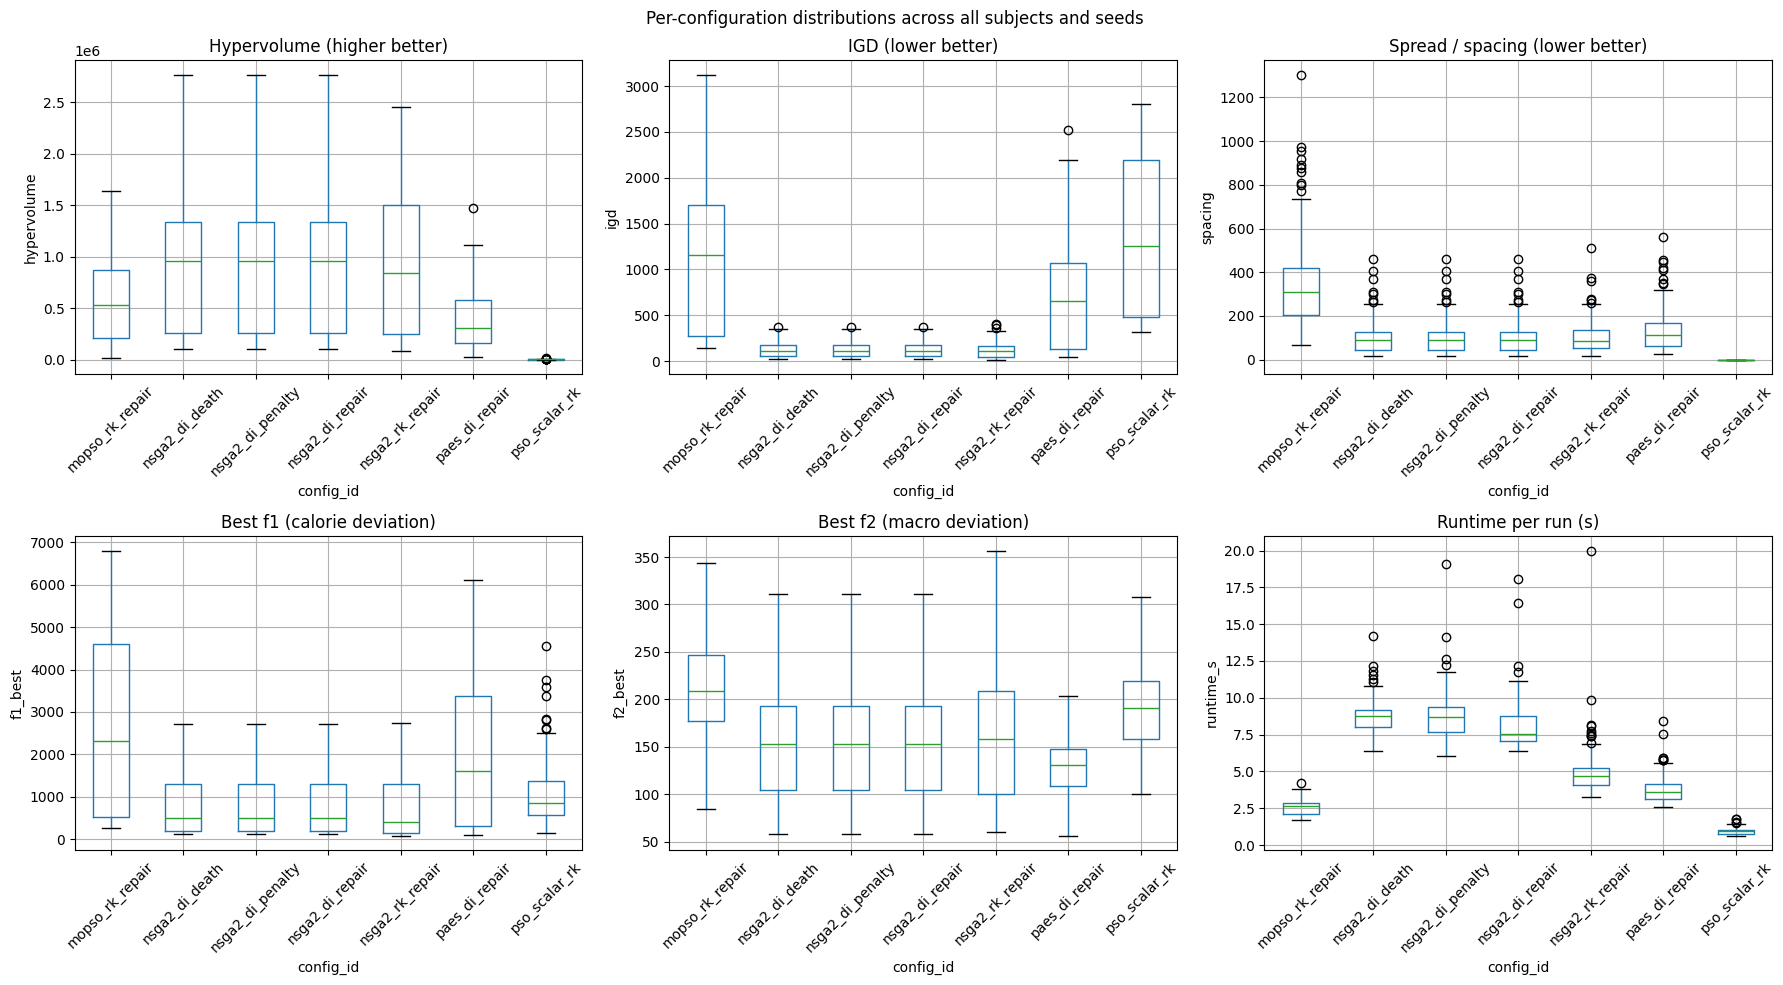

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
metrics = [('hypervolume', 'Hypervolume (higher better)'),
           ('igd', 'IGD (lower better)'),
           ('spacing', 'Spread / spacing (lower better)'),
           ('f1_best', 'Best f1 (calorie deviation)'),
           ('f2_best', 'Best f2 (macro deviation)'),
           ('runtime_s', 'Runtime per run (s)')]
for ax, (m, title) in zip(axes.flat, metrics):
    plot_metric_box(all_runs, m, 'config_id', ax, title=title)
    ax.tick_params(axis='x', rotation=45)
plt.suptitle('Per-configuration distributions across all subjects and seeds')
plt.tight_layout()
plt.savefig('experiments/boxplots.png', dpi=150)
plt.show()

## 7. Statistical tests

**Friedman omnibus + average ranks** test whether at least one configuration differs significantly from the others on hypervolume.

**Pairwise Mann-Whitney U with Holm correction** provides pairwise significance tests adjusted for multiple comparisons.

In [11]:
samples_hv = {cfg: all_runs[all_runs.config_id == cfg].hypervolume.tolist() for cfg in sorted(all_runs.config_id.unique())}
stat, p = friedman_test(samples_hv)
print(f'Friedman on hypervolume: stat={stat:.4f}  p={p:.4g}')

ranks = average_ranks(samples_hv, lower_is_better=False)
print('\nAverage ranks (best first):')
display(ranks.to_frame('avg_rank'))

pairwise_hv = pairwise_post_hoc(samples_hv)
pairwise_hv.to_csv('experiments/pairwise_hv.csv', index=False)
display(pairwise_hv.sort_values('p_adj').head(20))

Friedman on hypervolume: stat=545.2646  p=1.481e-114

Average ranks (best first):


,avg_rank
nsga2_di_death,2.813333
nsga2_di_penalty,2.813333
nsga2_di_repair,2.813333
nsga2_rk_repair,3.020000
mopso_rk_repair,4.333333
paes_di_repair,5.206667
pso_scalar_rk,7.000000


,config_a,config_b,p_raw,p_adj
5,mopso_rk_repair,pso_scalar_rk,1.079428e-50,2.266799e-49
10,nsga2_di_death,pso_scalar_rk,1.079428e-50,2.266799e-49
14,nsga2_di_penalty,pso_scalar_rk,1.079428e-50,2.266799e-49
17,nsga2_di_repair,pso_scalar_rk,1.079428e-50,2.266799e-49
19,nsga2_rk_repair,pso_scalar_rk,1.079428e-50,2.266799e-49
20,paes_di_repair,pso_scalar_rk,1.079428e-50,2.266799e-49
9,nsga2_di_death,paes_di_repair,5.541025e-13,8.311537e-12
13,nsga2_di_penalty,paes_di_repair,5.541025e-13,8.311537e-12
16,nsga2_di_repair,paes_di_repair,5.541025e-13,8.311537e-12
18,nsga2_rk_repair,paes_di_repair,3.019846e-11,3.623815e-10


In [12]:
samples_igd = {cfg: all_runs[all_runs.config_id == cfg].igd.tolist() for cfg in sorted(all_runs.config_id.unique())}
samples_runtime = {cfg: all_runs[all_runs.config_id == cfg].runtime_s.tolist() for cfg in sorted(all_runs.config_id.unique())}
for label, samples, lower in [('IGD', samples_igd, True), ('runtime', samples_runtime, True)]:
    stat, p = friedman_test(samples)
    print(f'\nFriedman on {label}: stat={stat:.4f}  p={p:.4g}')
    display(average_ranks(samples, lower_is_better=lower).to_frame('avg_rank'))


Friedman on IGD: stat=764.5908  p=6.875e-162


,avg_rank
nsga2_rk_repair,2.173333
nsga2_di_death,2.633333
nsga2_di_repair,2.633333
nsga2_di_penalty,2.633333
paes_di_repair,5.066667
mopso_rk_repair,6.113333
pso_scalar_rk,6.746667



Friedman on runtime: stat=828.0743  p=1.322e-175


,avg_rank
pso_scalar_rk,1.000000
mopso_rk_repair,2.000000
paes_di_repair,3.073333
nsga2_rk_repair,4.033333
nsga2_di_repair,5.500000
nsga2_di_penalty,6.166667
nsga2_di_death,6.226667


## 8. Best-of-best front per algorithm (cross-seed Pareto union)

For the report, the cloud below shows the best (f1, f2) per run for the demo subject across all 30 seeds and all configurations.

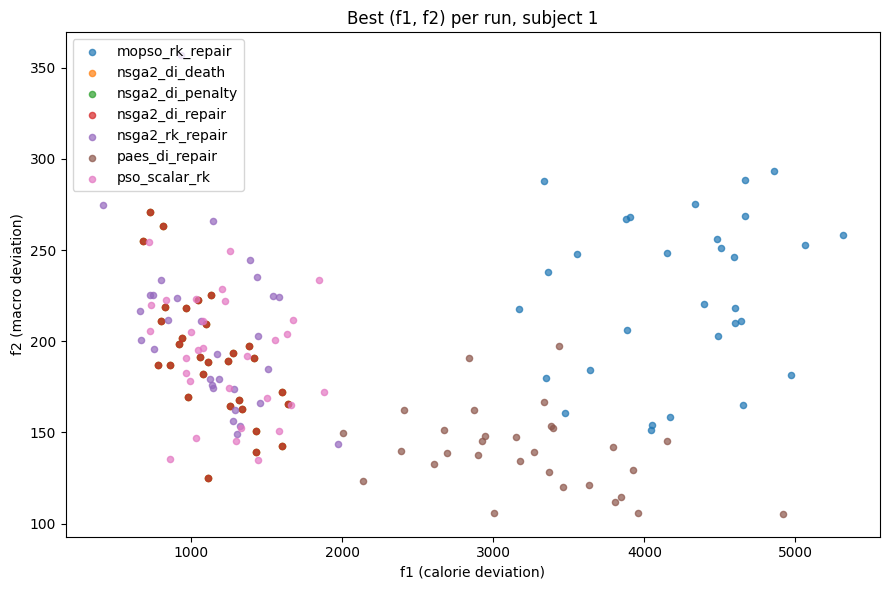

In [13]:
subj_id = demo_subject.sujeto_id
subset = all_runs[all_runs.subject_id == subj_id]

fig, ax = plt.subplots(figsize=(9, 6))
for cfg, group in subset.groupby('config_id'):
    pts = list(zip(group.f1_best, group.f2_best))
    plot_pareto(pts, ax, label=cfg)
ax.legend()
ax.set_title(f'Best (f1, f2) per run, subject {subj_id}')
plt.tight_layout()
plt.savefig(f'experiments/best_pts_subject_{subj_id}.png', dpi=150)
plt.show()